# Biologically Plausible Learning Comparision for Medical AI


In [1]:
# imports
import time
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from imblearn.over_sampling import BorderlineSMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTEENN

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import os
os.makedirs("learning_results/models", exist_ok=True)
os.makedirs("learning_results/plots", exist_ok=True)

Using device: cuda


### Dataset
 
Wisconsin Dataset: Tabular Data

In [2]:
df = pd.read_csv("stroke_cleaned.csv")

X = df.drop(columns=["stroke"])
y = df["stroke"]

FEATURE_NAMES = X.columns

df = X.copy()
df["target"] = y
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,target
0,1,67,0,1,1,2,1,228.69,36.6,1,1
1,0,61,0,0,1,3,0,202.21,28.1,2,1
2,1,80,0,1,1,2,0,105.92,32.5,2,1
3,0,49,0,0,1,2,1,171.23,34.4,3,1
4,0,79,1,0,1,3,0,174.12,24.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
4990,0,80,1,0,1,2,1,83.75,28.1,2,0
4991,0,81,0,0,1,3,1,125.20,40.0,2,0
4992,0,35,0,0,1,3,0,82.99,30.6,2,0
4993,1,51,0,0,1,2,0,166.29,25.6,1,0


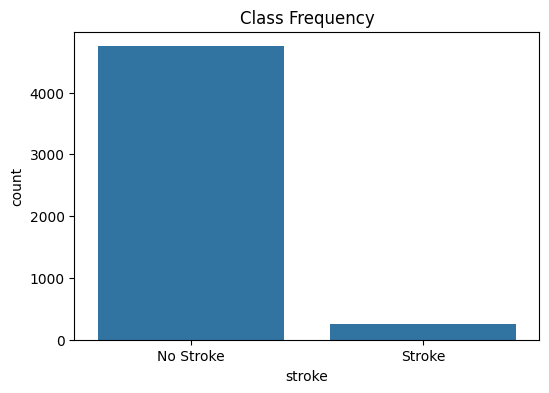

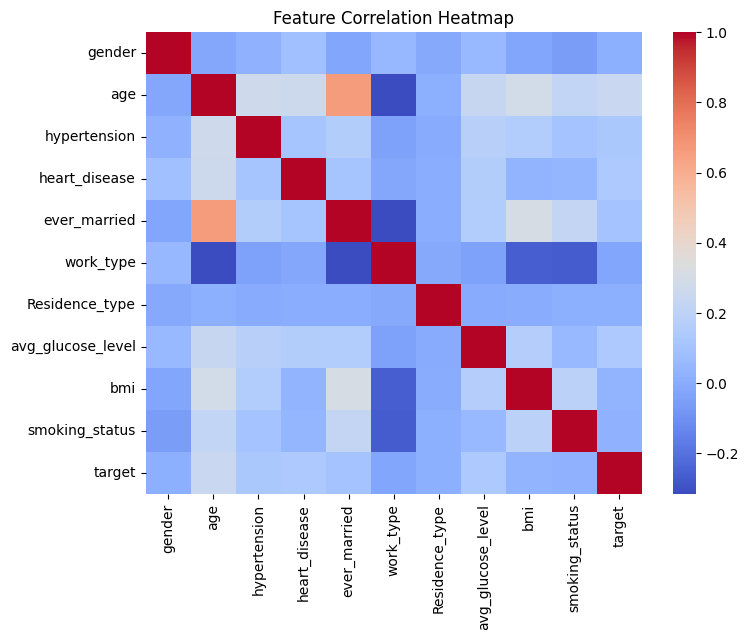

Top correlated features with target:
 work_type           -0.026045
gender               0.010891
Residence_type       0.014820
smoking_status       0.023122
bmi                  0.030233
ever_married         0.105015
hypertension         0.126971
avg_glucose_level    0.132418
heart_disease        0.134314
age                  0.247975
Name: target, dtype: float64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Frequency")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.show()

corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

target_corr = corr['target'].drop('target').sort_values(ascending=True)
print("Top correlated features with target:\n", target_corr)

what to do with this info? delete irrelevant features.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# target_corr = X_train.corrwith(y_train)

# threshold = 0.2
# selected_features = target_corr[target_corr.abs() > threshold].index.tolist()
# deleted_features = target_corr[target_corr.abs() <= threshold].index.tolist()

# print(f"Selected features ({len(selected_features)}):\n{selected_features}\n")
# print(f"Deleted features ({len(deleted_features)}):\n{deleted_features}\n")

# X_train = X_train[selected_features]
# X_test = X_test[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# target_corr = X_train.corrwith(y_train)

# threshold = 0.2
# selected_features = target_corr[target_corr.abs() > threshold].index.tolist()
# deleted_features = target_corr[target_corr.abs() <= threshold].index.tolist()

# print(f"Selected features ({len(selected_features)}):\n{selected_features}\n")
# print(f"Deleted features ({len(deleted_features)}):\n{deleted_features}\n")

# X_train = X_train[selected_features]
# X_test = X_test[selected_features]

input_dim = X_train.shape[1]
output_dim = 2  # Binary classification
print(f"Input Features: {input_dim}, Output Classes: {output_dim}")

def prepare_data(imbalance_mode):
    scaler = StandardScaler()
    # scaling after oversampling lead to synthetic data leakage, but is that really a leakage?
    if imbalance_mode == "oversample":
        sm = BorderlineSMOTE(sampling_strategy='minority', random_state=seed)  # RandomOversampler may cause overfitting, use ADASYN only if class imbalance too high; Borderline > SMOTE to preserve biologically coherent features
        print("Oversampling method: ", sm)
        scaler.fit(X_train)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
        X_train_scaled = scaler.transform(X_train_res)
    else:
        X_train_scaled = scaler.fit_transform(X_train)
        y_train_res = y_train
    X_test_scaled = scaler.transform(X_test)

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train_res, dtype=torch.long).to(device)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

    class_counts = np.bincount(y_train_tensor.cpu().numpy())
    print(", ".join([f"Class {i}: {count}" for i, count in enumerate(class_counts)]))

    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, scaler

X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, scaler = prepare_data(imbalance_mode="oversample")

Input Features: 10, Output Classes: 2
Oversampling method:  BorderlineSMOTE(random_state=42, sampling_strategy='minority')
Class 0: 3798, Class 1: 3798


## Feedforward Architecture with Backprop

Constant width

In [5]:
input_dim = X_train.shape[1]
hidden_dim = [32, 16]
output_dim = 2

print(f"Input Features: {input_dim}, Hidden Dimensions: {hidden_dim}")

class BPNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(BPNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim[0]),
            nn.ReLU(),
            nn.Linear(hidden_dim[0], hidden_dim[1]),
            nn.ReLU(),
            nn.Linear(hidden_dim[1], output_dim)
        )
    def forward(self, x):
        return self.net(x)

Input Features: 10, Hidden Dimensions: [32, 16]


Training

Epoch 1/128 | Train Loss: 0.6995, Test Loss: 0.6049, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 8/128 | Train Loss: 0.6861, Test Loss: 0.6131, Train Acc: 0.5068, Test Acc: 0.9449
Epoch 16/128 | Train Loss: 0.6712, Test Loss: 0.6149, Train Acc: 0.5994, Test Acc: 0.9109
Epoch 24/128 | Train Loss: 0.6540, Test Loss: 0.6090, Train Acc: 0.6983, Test Acc: 0.8579
Epoch 32/128 | Train Loss: 0.6311, Test Loss: 0.5946, Train Acc: 0.7613, Test Acc: 0.8158
Epoch 40/128 | Train Loss: 0.6014, Test Loss: 0.5736, Train Acc: 0.7919, Test Acc: 0.7788
Epoch 48/128 | Train Loss: 0.5643, Test Loss: 0.5492, Train Acc: 0.8067, Test Acc: 0.7578
Epoch 56/128 | Train Loss: 0.5215, Test Loss: 0.5241, Train Acc: 0.8170, Test Acc: 0.7437
Epoch 64/128 | Train Loss: 0.4775, Test Loss: 0.4974, Train Acc: 0.8285, Test Acc: 0.7467
Epoch 72/128 | Train Loss: 0.4372, Test Loss: 0.4689, Train Acc: 0.8358, Test Acc: 0.7668
Epoch 80/128 | Train Loss: 0.4031, Test Loss: 0.4413, Train Acc: 0.8439, Test Acc: 0.7808
Epoch 88/128

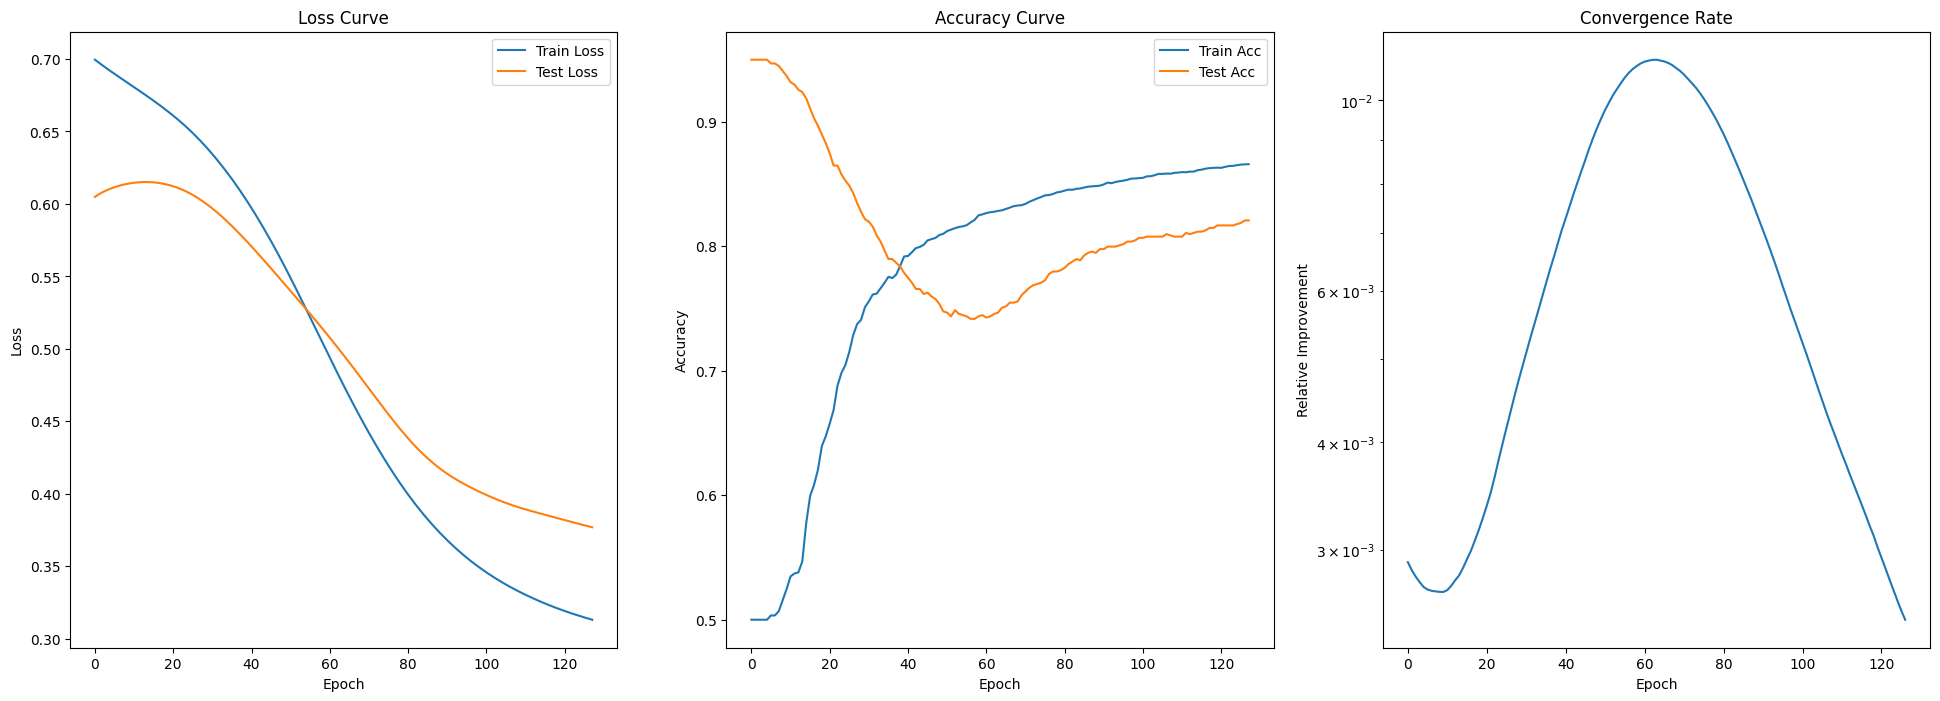

In [6]:
model = BPNN(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model_name = "BPNN"
results = {
    "epochs": [],
    "final": {}
}

epochs = 128
train_losses, test_losses = [], []
train_accs, test_accs = [], []

grad_norms = []
weight_updates = []
convergence_rates = []

bp_ref_grads = []   # for cosine similarity

prev_loss = None

start_time = time.perf_counter()
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Training
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    
    # Gradients norm and ref
    grads = []
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
            total_norm += p.grad.norm(2).item() ** 2
    bp_ref_grads.append(torch.cat(grads).detach().cpu().numpy())
    grad_norm = total_norm**0.5
    grad_norms.append(grad_norm)
    
    # Update weights
    old_weights = [p.clone() for p in model.parameters()]
    optimizer.step()    
    update_norm = 0
    for old, new in zip(old_weights, model.parameters()):
        update_norm += (new - old).norm(2).item() ** 2
    weight_update_norm = update_norm**0.5
    weight_updates.append(weight_update_norm)
    
    # Convergence Rate
    if prev_loss is not None:
        improvement = abs(prev_loss - loss.item())
        rate = improvement / prev_loss if prev_loss > 0 else 0
    else: rate = None
    convergence_rates.append(rate)
    prev_loss = loss.item()

    # Metrics
    preds_train = outputs.argmax(dim=1)
    train_acc = (preds_train == y_train_tensor).float().mean().item()
    train_losses.append(loss.item())
    train_accs.append(train_acc)
    

    # Validation metrics
    model.eval()
    with torch.no_grad():
        test_out = model(X_test_tensor)
        test_loss = criterion(test_out, y_test_tensor).item()
        test_preds = test_out.argmax(dim=1)
        test_acc = (test_preds == y_test_tensor).float().mean().item()
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    

    results["epochs"].append({
        "epoch": epoch+1,
        "train_loss": loss.item(),
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "grad_norm": grad_norm,
        "weight_update_norm": weight_update_norm,
        "convergence_rate" : rate
    })

    if not epoch or not (epoch+1)%8: 
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f}, Test Loss: {test_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

end_time = time.perf_counter()
elapsed = end_time - start_time
print(f"\nTraining completed in {elapsed:.2f} seconds")

convergence_rate_bnn = convergence_rates[-1]

# Plots
plt.figure(figsize=(24, 8))

# Loss curve
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy curve
plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Convergence rate
plt.subplot(1, 3, 3)
plt.plot([r for r in convergence_rates if r is not None])
plt.title("Convergence Rate")
plt.xlabel("Epoch")
plt.ylabel("Relative Improvement")
plt.yscale("log")
plt.show()

bp_ref_grads = np.array(bp_ref_grads)
torch.save(model.state_dict(), "learning_results/models/bp_model.pth")

Train and test are close --> no major underfitting or overfitting. Test > Test plausible for small dataset due to higher impact of noise and test dataset being "easier" than train.

Eval

In [7]:
y_true = y_test_tensor.cpu().numpy()
y_pred = test_preds.cpu().numpy()
probs = torch.softmax(test_out, dim=1)[:, 1].cpu().numpy()
report = classification_report(y_true, y_pred, output_dict=True)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))
print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_true, probs):.4f}")
print(f"Final Accuracy: {test_accs[-1]*100:.2f}%")

results["final"] = {
    "training_time": elapsed,
    "f1_score": f1_score(y_true, y_pred),
    "roc_auc": roc_auc_score(y_true, probs),
    "accuracy": test_accs[-1],
    "precision_0": report["0"]["precision"],
    "recall_0": report["0"]["recall"],
    "precision_1": report["1"]["precision"],
    "recall_1": report["1"]["recall"],
    "final_convergence_rate": convergence_rate_bnn,
    "convergence_epoch": epochs,
    "bp_ref_grads": bp_ref_grads.tolist()
}


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       949
           1       0.15      0.56      0.24        50

    accuracy                           0.82       999
   macro avg       0.56      0.70      0.57       999
weighted avg       0.93      0.82      0.87       999

F1 Score: 0.2383
ROC AUC: 0.7865
Final Accuracy: 82.08%


Save results

In [8]:
json_path = "learning_results/learning_comparison_results.json"
if os.path.exists(json_path):
    with open(json_path, "r") as f:
        all_results = json.load(f)
else: all_results = {}

all_results[model_name] = results

with open(json_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Results for {model_name} saved to {json_path}")
# print(json.dumps(results, indent=4))

Results for BPNN saved to learning_results/learning_comparison_results.json


---

# FF Architecture with Direct Feedback Alignment 
per Lillicrap et al. (2016).

Same Network

In [9]:
input_dim = X_train.shape[1]
hidden_dim = [32, 16]
output_dim = 2

print(f"Input Features: {input_dim}, Hidden Dimensions: {hidden_dim}")

class DFANN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DFANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim[0]),
            nn.ReLU(),
            nn.Linear(hidden_dim[0], hidden_dim[1]),
            nn.ReLU(),
            nn.Linear(hidden_dim[1], output_dim)
        )
    def forward(self, x):
        return self.net(x)

Input Features: 10, Hidden Dimensions: [32, 16]


Epoch 2/256 | Train Loss: 0.6954, Test Loss: 0.5765, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 3/256 | Train Loss: 0.6955, Test Loss: 0.5774, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 4/256 | Train Loss: 0.6956, Test Loss: 0.5783, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 5/256 | Train Loss: 0.6957, Test Loss: 0.5793, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 6/256 | Train Loss: 0.6957, Test Loss: 0.5803, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 7/256 | Train Loss: 0.6956, Test Loss: 0.5815, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 8/256 | Train Loss: 0.6955, Test Loss: 0.5827, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 9/256 | Train Loss: 0.6952, Test Loss: 0.5840, Train Acc: 0.5000, Test Acc: 0.9499
Epoch 10/256 | Train Loss: 0.6950, Test Loss: 0.5854, Train Acc: 0.4999, Test Acc: 0.9499
Epoch 11/256 | Train Loss: 0.6946, Test Loss: 0.5868, Train Acc: 0.5003, Test Acc: 0.9499
Epoch 12/256 | Train Loss: 0.6942, Test Loss: 0.5884, Train Acc: 0.5004, Test Acc: 0.9489
Epoch 13/256 | Tra

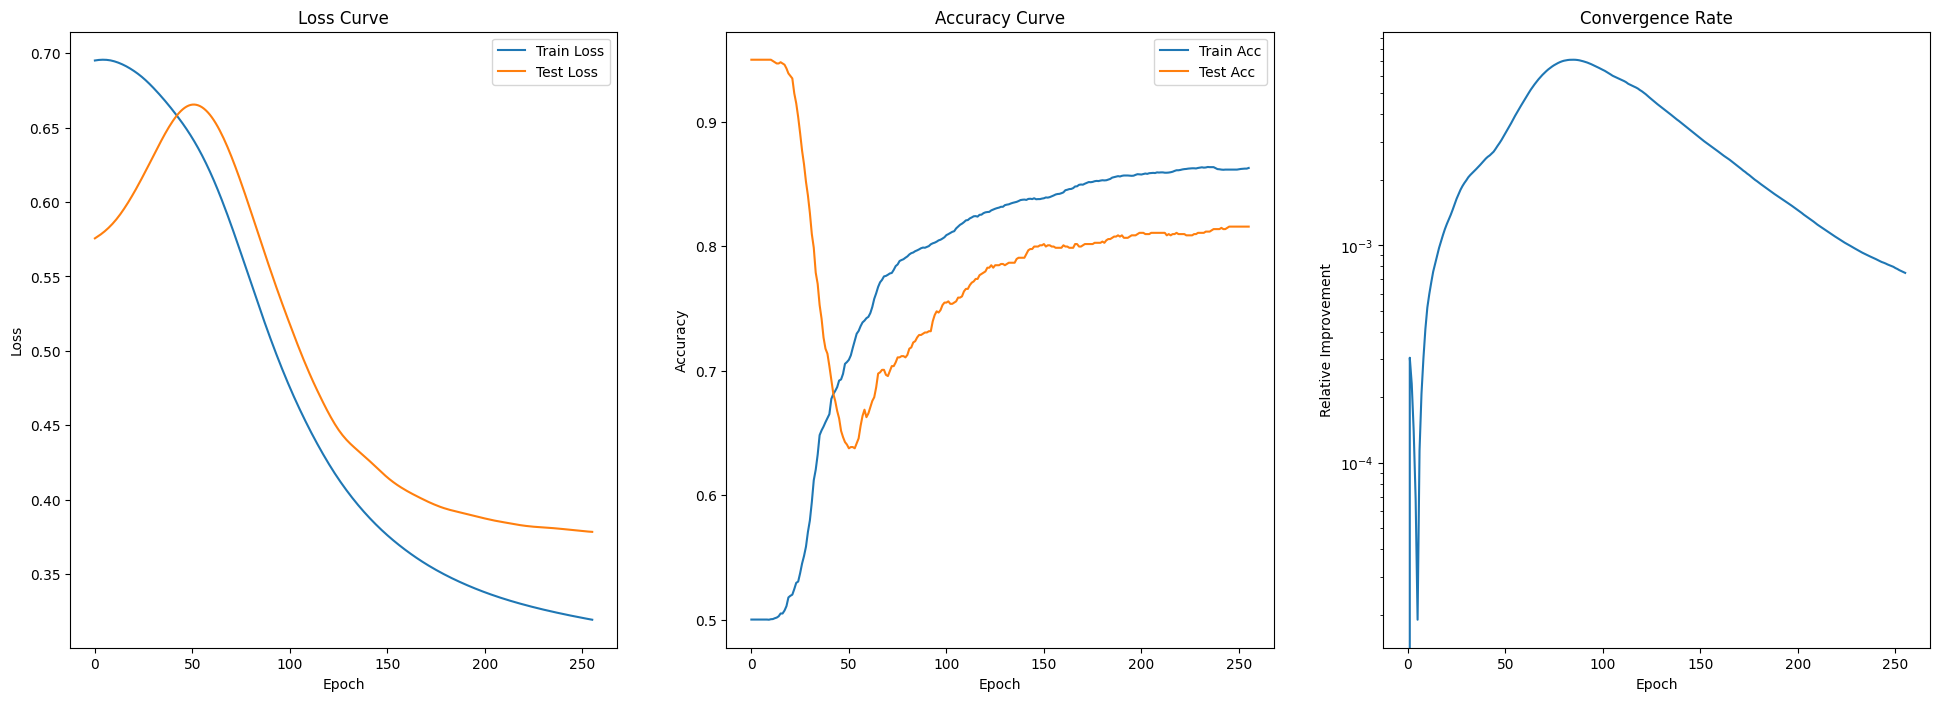

In [10]:
# --- same ---
model = DFANN(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# -- same ---


# --- DFA ---
# Initialize fixed random feedback matrices B^l for each hidden layer
# Here, model.net = [Linear1, ReLU, Linear2, ReLU, Linear3] with 3 linears
B = []
linear_layers = [m for m in model.net if isinstance(m, nn.Linear)]
num_layers = len(linear_layers)
for idx, layer in enumerate(linear_layers[:-1]):  # skip last (output) layer
    n_hidden = layer.out_features
    # normalise feedback matrix | To keep the scale of the feedback roughly same regardless of output size
    B_mat = torch.randn(n_hidden, output_dim, device=device) / (output_dim ** 0.5)  # for each hidden layer l, we sample a random matrix B^l ∈ R^{n_l x n_{l+1}} \in N(0,1/sqrt(n_{l+1}))
    B.append(B_mat)

# --- same ---
model_name = "DFANN"
results = {
    "epochs": [],
    "final": {}
}

epochs = 256   # extra to compare convergence
train_losses, test_losses = [], []
train_accs, test_accs = [], []

grad_norms = []
weight_updates = []
convergence_rates = []

cosine_similarities = []

prev_loss = None

start_time = time.perf_counter()
# --- same ---

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    

    # --- Manual forward with activations & pre-activations for DFA --- ~ similar
    activations = [X_train_tensor.to(device)]  # a^0 = x, a^l = \sigma(z^l)
    preacts = []                    # z^l = W^l a^{l-1} + b^l
    for layer in linear_layers:
        x = activations[-1]     # a^{l-1}
        z = layer(x)            # z^l = W^l a^{l-1} + b^l
        preacts.append(z)
        # apply ReLU for hidden, identity for last
        a = torch.relu(z) if layer is not linear_layers[-1] else z
        activations.append(a)
    outputs = activations[-1]  # logits
    # --- Manual forward with activations & pre-activations for DFA --- ~ similar

    loss = criterion(outputs, y_train_tensor.to(device))
    
    # --- DFA deltas ---
    batch_size = outputs.size(0)
    with torch.no_grad():
        probs = torch.softmax(outputs, dim=1)
        delta_L = probs - torch.nn.functional.one_hot(y_train_tensor.to(device), num_classes=output_dim).float()  # Output layer delta: \delta^L = p - y
    deltas = [None] * num_layers
    deltas[-1] = delta_L
    # hidden layer update
    for l in range(num_layers-1):
        z = preacts[l]
        fb = delta_L @ B[l].T   # direct feedback projection of output loss = delta^L X B^l X; (B X O) X (O X n_l) = (B X n_l); B = batch_size
        delta = fb * (z>0).float()
        deltas[l] = delta   # layer loss delta = deltas^l = fb * ReLU(z^l)
    # --- DFA deltas ---

    # --- Gradient Norm & manual gradients ---
    grads = []
    total_norm = 0.0
    for l, layer in enumerate(linear_layers):
        W = layer.weight
        a_prev = activations[l]
        delta = deltas[l]
        grad_W = (delta.T @ a_prev) / batch_size   # \nabla W^l = \delta^l X a^{l} / B
        grad_b = delta.sum(dim=0)                 # \nabla b^l = sum(\delta^l)
        W.grad = grad_W
        layer.bias.grad = grad_b
        grads.append(grad_W.view(-1))  # same order as bp appends
        grads.append(grad_b.view(-1))
        total_norm += grad_W.norm(2).item()**2 + grad_b.norm(2).item()**2
    grad_norm = total_norm**0.5
    grad_norms.append(grad_norm)
    # cosine similarity
    if epoch < 128: 
        dfa_grad = torch.cat(grads).detach().cpu()
        bp_ref_grad = torch.tensor(bp_ref_grads[epoch], dtype=torch.float32) 
        cos_sim = torch.nn.functional.cosine_similarity(
            dfa_grad.unsqueeze(0), bp_ref_grad.unsqueeze(0)
        ).item(); cosine_similarities.append(cos_sim)   
    # --- Gradient Norm ---


    # --- same ---

    # Update weights
    old_weights = [p.clone() for p in model.parameters()]
    optimizer.step()    
    update_norm = 0
    for old, new in zip(old_weights, model.parameters()):
        update_norm += (new - old).norm(2).item() ** 2
    weight_update_norm = update_norm ** 0.5
    weight_updates.append(weight_update_norm)
    
    # Convergence Rate
    cur_loss = loss.item()
    if prev_loss is not None and prev_loss > 0:
        improvement = abs(prev_loss - cur_loss)
        rate = improvement / prev_loss
    else:
        rate = 0.0
    convergence_rates.append(rate)
    prev_loss = cur_loss
    
    # Metrics
    preds_train = outputs.argmax(dim=1)
    train_acc = (preds_train == y_train_tensor.to(device)).float().mean().item()
    train_losses.append(cur_loss)
    train_accs.append(train_acc)
    

    # Validation metrics
    model.eval()
    with torch.no_grad():
        test_out = model(X_test_tensor.to(device))
        test_loss = criterion(test_out, y_test_tensor.to(device)).item()
        test_preds = test_out.argmax(dim=1)
        test_acc = (test_preds == y_test_tensor.to(device)).float().mean().item()
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    

    results["epochs"].append({
        "epoch": epoch + 1,
        "train_loss": cur_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "grad_norm": grad_norm,
        "weight_update_norm": weight_update_norm,
        "convergence_rate" : rate
    })

    if not epoch == 0 or not (epoch+1)%8:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {cur_loss:.4f}, Test Loss: {test_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
    
end_time = time.perf_counter()
elapsed = end_time - start_time
print(f"\nTraining completed in {elapsed:.2f} seconds")

convergence_rate_dfa = convergence_rates[-1]
print(f"Final Convergence Rate: {convergence_rate_dfa:.4f}, Epoch: {epochs}")

# Plots
plt.figure(figsize=(24, 8))

# Loss curve
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy curve
plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Convergence rate
plt.subplot(1, 3, 3)
plt.plot(convergence_rates)
plt.title("Convergence Rate")
plt.xlabel("Epoch")
plt.ylabel("Relative Improvement")
plt.yscale("log")
plt.show()

torch.save(model.state_dict(), "learning_results/models/dfa_model.pth")

Same eval

In [11]:
y_true = y_test_tensor.cpu().numpy()
y_pred = test_preds.cpu().numpy()
probs = torch.softmax(test_out, dim=1)[:, 1].cpu().numpy()
report = classification_report(y_true, y_pred, output_dict=True)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))
print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_true, probs):.4f}")
print(f"Final Accuracy: {test_accs[-1]*100:.2f}%")\

results["final"] = {
    "training_time": elapsed,
    "f1_score": f1_score(y_true, y_pred),
    "roc_auc": roc_auc_score(y_true, probs),
    "accuracy": test_accs[-1],
    "precision_0": report["0"]["precision"],
    "recall_0": report["0"]["recall"],
    "precision_1": report["1"]["precision"],
    "recall_1": report["1"]["recall"],
    "final_convergence_rate": convergence_rate_dfa,
    "convergence_epoch": epochs,
    "cosine_similarities": cosine_similarities
}


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       949
           1       0.15      0.56      0.23        50

    accuracy                           0.82       999
   macro avg       0.56      0.69      0.56       999
weighted avg       0.93      0.82      0.86       999

F1 Score: 0.2333
ROC AUC: 0.8004
Final Accuracy: 81.58%


In [12]:
if os.path.exists(json_path):
    with open(json_path, "r") as f:
        all_results = json.load(f)
else: all_results = {}

all_results[model_name] = results

with open(json_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Results for {model_name} saved to {json_path}")
# print(json.dumps(results, indent=4))

Results for DFANN saved to learning_results/learning_comparison_results.json


### Comparison Plots

Cosine Similarity

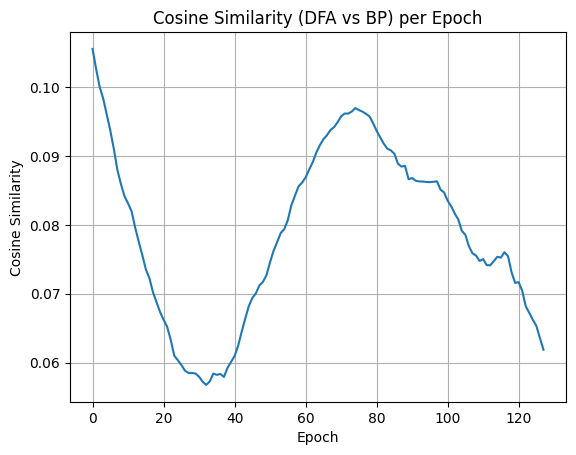

In [13]:
plt.plot(cosine_similarities)
plt.title("Cosine Similarity (DFA vs BP) per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cosine Similarity")
plt.grid(True)
plt.show()

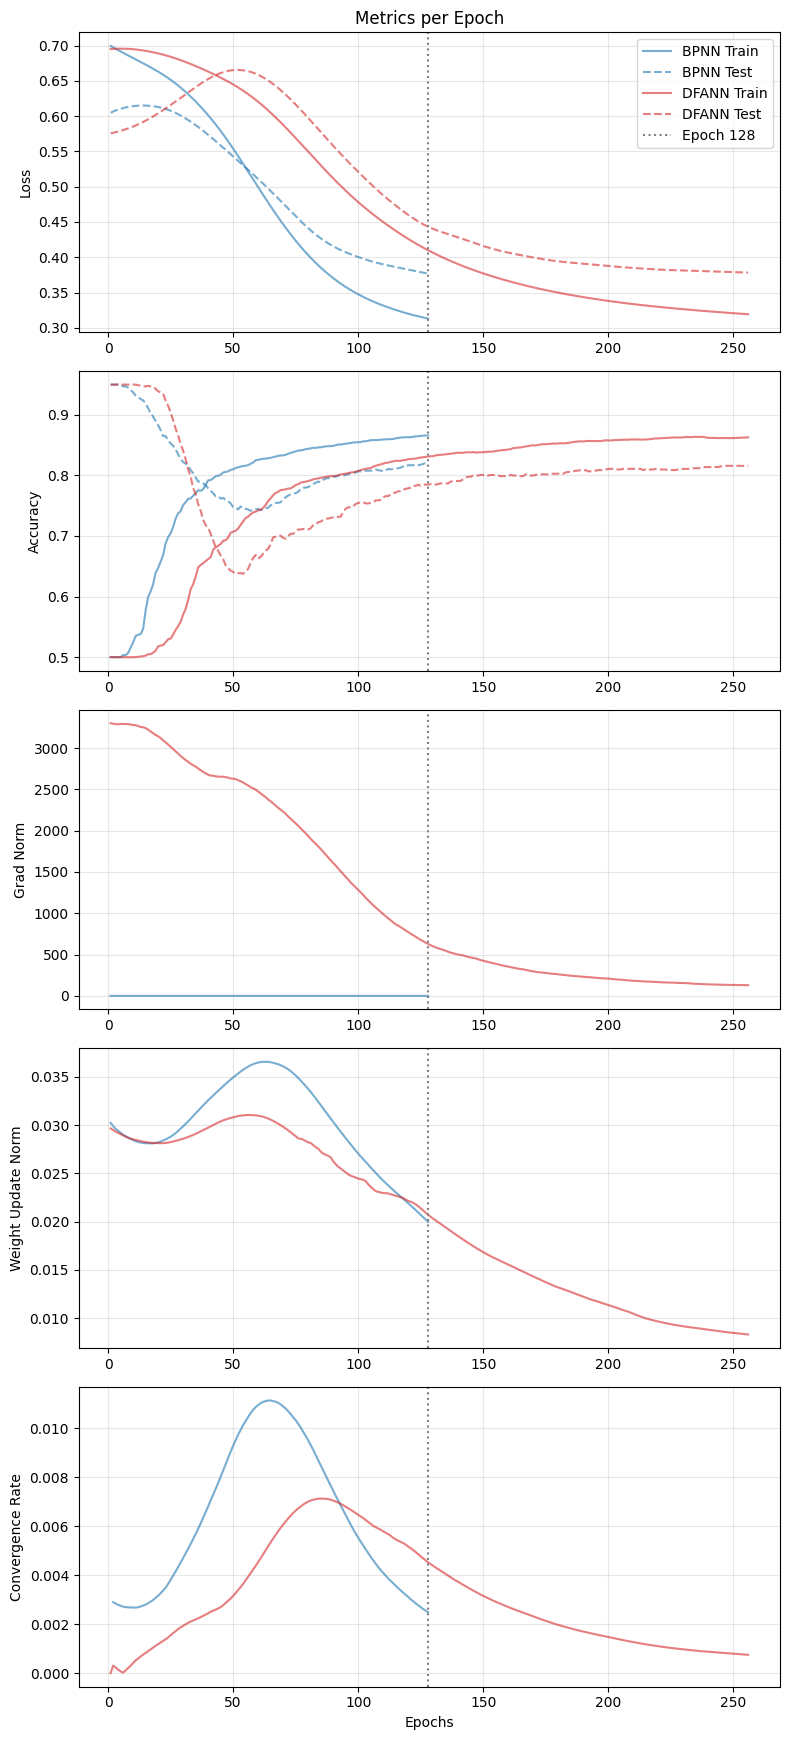


---- Final Metrics Comparison ----
                           BPNN    DFANN
training_time            1.1052   1.0641
f1_score                 0.2383   0.2333
roc_auc                  0.7865   0.8004
accuracy                 0.8208   0.8158
precision_0              0.9730   0.9728
recall_0                 0.8346   0.8293
precision_1              0.1514   0.1474
recall_1                 0.5600   0.5600
final_convergence_rate   0.0025   0.0007
convergence_epoch      128.0000 256.0000


In [14]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
with open("learning_results/learning_comparison_results.json", "r") as f:
    data = json.load(f)

models = list(data.keys())  # ['BPNN', 'DFANN']

# Define metric keys
epoch_metrics = [
    ("loss", "train_loss", "test_loss"),
    ("accuracy", "train_acc", "test_acc"),
    ("grad_norm", "grad_norm", None),
    ("weight_update_norm", "weight_update_norm", None),
    ("convergence_rate", "convergence_rate", None)
]

colors = {"BPNN": "tab:blue", "DFANN": "tab:red"}
alpha = 0.6
# Individual plots per metric
for metric_name, train_key, test_key in epoch_metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for model in models:
        epochs = [e["epoch"] for e in data[model]["epochs"]]
        # Train curve
        train_vals = [e[train_key] for e in data[model]["epochs"]]
        ax.plot(epochs, train_vals,
                color=colors[model], alpha=alpha,
                linestyle="-", label=f"{model} Train")
        # Test curve
        if test_key:
            test_vals = [e[test_key] for e in data[model]["epochs"]]
            ax.plot(epochs, test_vals,
                    color=colors[model], alpha=alpha,
                    linestyle="--", label=f"{model} Test")
    ax.axvline(x=128, color='gray', linestyle=':', linewidth=1.5, label='Epoch 128')
    ax.set_xlabel("Epochs")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_title(f"{metric_name.replace('_', ' ').title()} per Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"learning_results/plots/{metric_name}.png")
    plt.close(fig)

# Combined subplot with vertical line at epoch 128
fig, axes = plt.subplots(len(epoch_metrics), 1, figsize=(8, len(epoch_metrics)*3.5))
for ax, (metric_name, train_key, test_key) in zip(axes, epoch_metrics):
    for model in models:
        epochs = [e["epoch"] for e in data[model]["epochs"]]
        # Train curve
        train_vals = [e[train_key] for e in data[model]["epochs"]]
        ax.plot(epochs, train_vals,
                color=colors[model], alpha=alpha,
                linestyle="-", label=f"{model} Train")
        # Test curve
        if test_key:
            test_vals = [e[test_key] for e in data[model]["epochs"]]
            ax.plot(epochs, test_vals,
                    color=colors[model], alpha=alpha,
                    linestyle="--", label=f"{model} Test")
    ax.axvline(x=128, color='gray', linestyle=':', linewidth=1.5, label='Epoch 128' if ax is axes[0] else None)
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_title("Metrics per Epoch")
        ax.legend(loc="upper right")
    if ax is axes[-1]:
        ax.set_xlabel("Epochs")
fig.tight_layout()
plt.show()

# Final metric table
final_metrics_keys = [
    "training_time", "f1_score", "roc_auc", "accuracy",
    "precision_0", "recall_0", "precision_1", "recall_1",
    "final_convergence_rate", "convergence_epoch"
]

final_data = {
    model: [data[model]["final"].get(k, None) for k in final_metrics_keys]
    for model in models
}

df = pd.DataFrame(final_data, index=final_metrics_keys)
print("\n---- Final Metrics Comparison ----")
print(df.to_string(float_format="%.4f"))

### Interpretation

LOSS CURVE:  DFA’s random feedback path delivers a noisier, lower‑magnitude learning signal, so optimization is slower. But it ultimately reaches comparable loss, which shows the network can still discover a useful representation even without true backpropagation.

ACCURACY CURVE: Although DFANN catches up, it requires more training. This is because backprop aligns each hidden weight update directly with downstream error, whereas DFA injects error via a fixed random projection which must, over time, perhaps, maybe, should align the hidden features with the target.

GRAD NORM: Random feedback matrices produce large, inconsistent gradient magnitudes early on, which gradually shrink as the network weights learn to use these noisy signals. Backprop’s more precise gradients are lower‑variance, avoiding that initial spike.

WEIGHT NORM: Despite very different gradient sources, Adam’s adaptive moments normalize update scales so that the actual parameter moves remain roughly comparable. This helps DFANN avoid divergence even under noisy gradients. Without an adaptive optimiser the noisier dfa gradients would blow-up or vanish.

CONVERGENCE RATE: BP achieves most of its progress early on, then plateaus. DFA—lacking exact gradient alignment—has a delayed, stretched‑out learning curve.

RECALL/PERCISION/ACC: for both classes under DFANN indicates a small loss in decision‑boundary sharpness and accuracy.

!!! The inherent noise in DFA’s feedback can act like a regulariser, smoothing the loss landscape and sometimes improving generalisation.

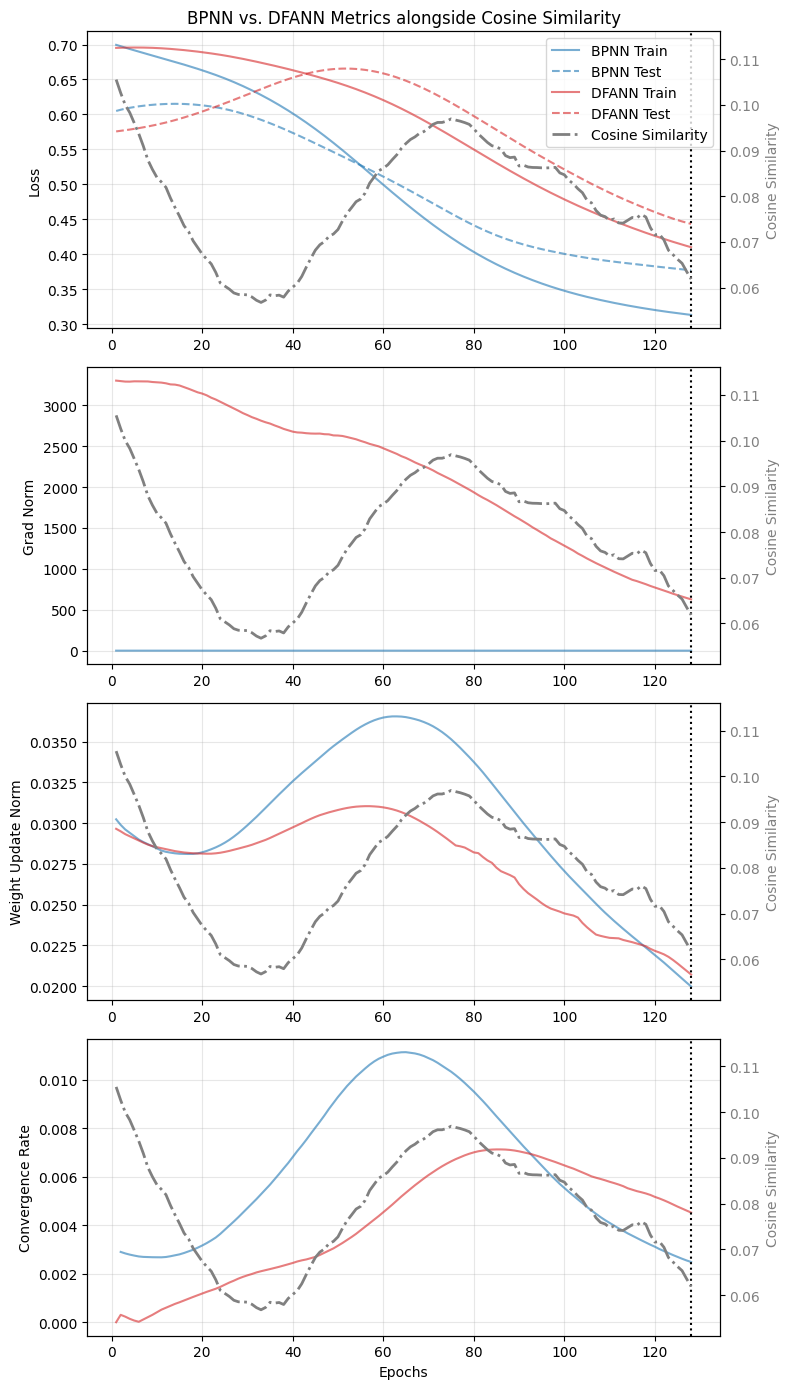

In [15]:
epoch_metrics = [("loss", "train_loss", "test_loss"), ("grad_norm", "grad_norm", None), ("weight_update_norm", "weight_update_norm", None), ("convergence_rate", "convergence_rate", None)]
filtered_epochs = {
    model: [e for e in data[model]["epochs"] if e["epoch"] <= 128]
    for model in models
}; epochs = [e["epoch"] for e in filtered_epochs["DFANN"]]

cos_vals = data["DFANN"]["final"]["cosine_similarities"]

fig, axes = plt.subplots(len(epoch_metrics), 1, figsize=(8, len(epoch_metrics) * 3.5))
for ax, (metric_name, train_key, test_key) in zip(axes, epoch_metrics):
    for model in models:
        train_vals = [e[train_key] for e in filtered_epochs[model]]
        ax.plot(epochs, train_vals, label=f"{model} Train", color=colors[model], linestyle="-", alpha=alpha)

        if test_key:
            test_vals = [e[test_key] for e in filtered_epochs[model]]
            ax.plot(epochs, test_vals, label=f"{model} Test", color=colors[model], linestyle="--", alpha=alpha)

    ax2 = ax.twinx()
    ax2.plot(epochs, cos_vals, color="gray", linestyle="-.", linewidth=2, label="Cosine Similarity")
    ax2.set_ylabel("Cosine Similarity", color="gray")
    ax2.tick_params(axis='y', labelcolor="gray")
    ax2.set_ylim(min(cos_vals)*0.9, max(cos_vals)*1.1)

    ax.axvline(x=128, color='black', linestyle=':', linewidth=1.5)
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.grid(alpha=0.3)

    if ax is axes[0]:
        ax.set_title("BPNN vs. DFANN Metrics alongside Cosine Similarity")
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

axes[-1].set_xlabel("Epochs")
plt.tight_layout()
plt.savefig("learning_results/plots/cosine_similarity.png", bbox_inches='tight') 
plt.show()

Loss: The early peak in cosine similarity aligns with the initial drop in DFA loss, supporting the idea that early alignment with BP helps DFA get started. As the similarity declines, DFA continues to learn but at a slower rate. Gradient alignment helps early training, DFA can still reduce loss later even with unaligned updates.


Grad Norm: The cosine similarity curve follows an opposite trend to the DFA gradient norm. When the gradients are large and noisy, similarity is low. Once the DFA gradients shrink and stabilize, the similarity slowly increases. This implies that high-magnitude, noisy gradients in DFA tend to point in directions that differ more from BP.


Weight update norms: The cosine similarity curve dips when DFA’s update norm spikes, reflecting more misaligned learning directions. However, overall update norms converge, showing that both models adjust weights at similar scales despite different gradient directions.


Convergence rate: Even when gradients are misaligned, DFA continues to improve. This shows that DFA can still converge well using fixed feedback, without needing gradients that closely match BP. But is it the optimizer or the learning dynamics?

---

## What does the model learn? Feature attribution analysis: SHAP

In [16]:
import shap
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

# ----- Load models -----
bp_model = BPNN(input_dim, hidden_dim, output_dim).cpu()
bp_model.load_state_dict(torch.load("learning_results/models/bp_model.pth"))
bp_model.eval()

dfa_model = DFANN(input_dim, hidden_dim, output_dim).cpu()
dfa_model.load_state_dict(torch.load("learning_results/models/dfa_model.pth"))
dfa_model.eval()

# ----- 

X_test_shap = torch.tensor(X_test.to_numpy(), dtype=torch.float32)     # input

# SHAP explanations
explainer_bp = shap.DeepExplainer(bp_model, X_test_shap)
explainer_dfa = shap.DeepExplainer(dfa_model, X_test_shap)

shap_vals_bp = explainer_bp.shap_values(X_test_shap)
shap_vals_dfa = explainer_dfa.shap_values(X_test_shap)


print(shap_vals_bp.shape, shap_vals_dfa.shape)

(999, 10, 2) (999, 10, 2)


In [ ]:
# ----- Extract class 1 (+ve) attributions -----
bp_attr = shap_vals_bp[:, :, 1]
dfa_attr = shap_vals_dfa[:, :, 1] # (num_samples, num_features)

# Attribution Stats

# Global Spearman Correlation
mean_bp = np.mean(np.abs(bp_attr), axis=0)
mean_dfa = np.mean(np.abs(dfa_attr), axis=0)
global_spearman, pval = spearmanr(mean_bp, mean_dfa)

# Mean Cosine Similarity
cosines = []
for i in range(len(bp_attr)):
    a = bp_attr[i].reshape(1, -1)
    b = dfa_attr[i].reshape(1, -1)
    cos = cosine_similarity(a, b)[0, 0]
    cosines.append(cos)
mean_cosine = np.mean(cosines)

# Top-k Overlap
def topk_overlap(a, b, k):
    top_a = set(np.argsort(np.abs(a))[-k:])
    top_b = set(np.argsort(np.abs(b))[-k:])
    return len(top_a & top_b) / k
k = 4
overlaps = [topk_overlap(bp_attr[i], dfa_attr[i], k) for i in range(len(bp_attr))]
mean_topk_overlap = np.mean(overlaps)


print("---- SHAP Attribution Comparison ---\n")
print(f"Global Spearman Correlation, p-value:  {global_spearman:.4f}, {pval:.4f}")
print(f"Mean Cosine Similarity:                {mean_cosine:.4f}")
print(f"Mean Top-{k} Overlap:                    {mean_topk_overlap:.4f}")

---- SHAP Attribution Comparison ---

Global Spearman Correlation, p-value:  0.9152, 0.0002
Mean Cosine Similarity:                0.9845
Mean Top-4 Overlap:                    0.8964


The two models agree somewhat on what features matter globally, but there are notable differences.

High similarity in instance-level feature attributions, i.e., for most individual predictions, the direction and strength of SHAP values from both models are similar?? Also might indicate that many features are irrelavant to MOST decisions, thus not assignmed significatn weight by any model -> similar grads.

On average, ~ 55% of the top-8 most important features overlap per instance. Again, partial global agreement.

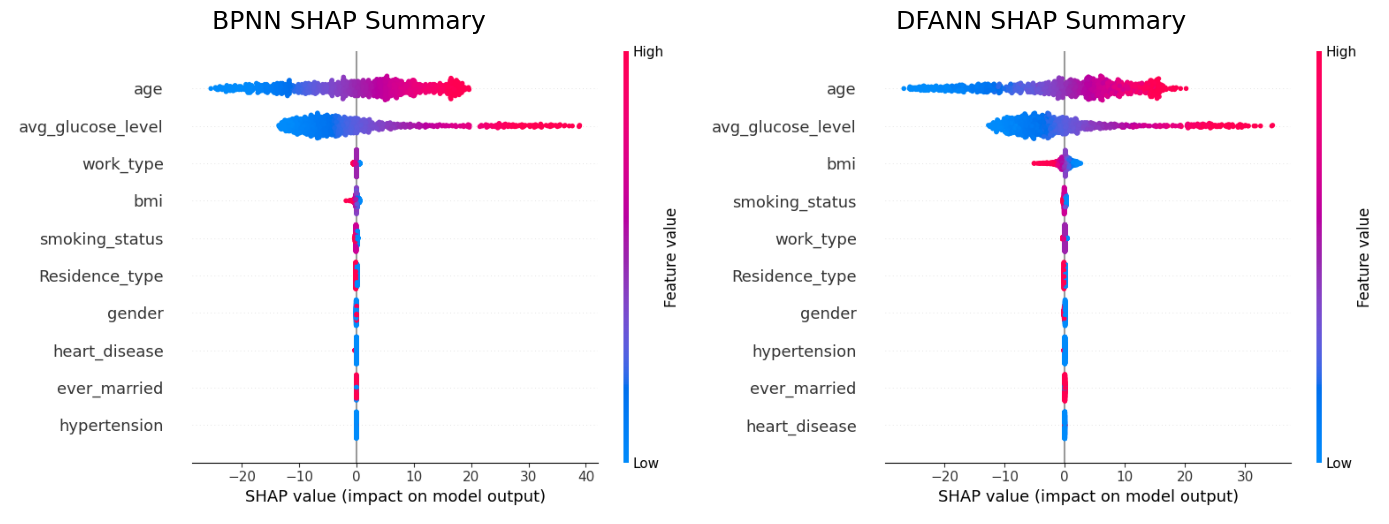

In [ ]:
# SHAP plots
shap.summary_plot(bp_attr, features=X_test, feature_names=FEATURE_NAMES, show=False)
plt.savefig("learning_results/plots/bp_shap.png", bbox_inches='tight')
plt.close()

shap.summary_plot(dfa_attr, features=X_test, feature_names=FEATURE_NAMES, show=False)
plt.savefig("learning_results/plots/df_shap.png", bbox_inches='tight')
plt.close()

import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(mpimg.imread("learning_results/plots/bp_shap.png"))
axes[0].axis('off')
axes[0].set_title("BPNN SHAP Summary", fontsize=18)

axes[1].imshow(mpimg.imread("learning_results/plots/df_shap.png"))
axes[1].axis('off')
axes[1].set_title("DFANN SHAP Summary", fontsize=18)

plt.tight_layout()
plt.savefig("learning_results/plots/combined_shap_summary.png", bbox_inches='tight') 
plt.show()

stroke -> right, no stroke -> left

colour = feaeture val

individual dots = individual sample analysis

In [19]:
bp_ranked_indices = np.argsort(-np.mean(np.abs(bp_attr), axis=0))
dfa_ranked_indices = np.argsort(-np.mean(np.abs(dfa_attr), axis=0))

# Top 10 features
top_10_bp = bp_ranked_indices[:10]
top_10_dfa = dfa_ranked_indices[:10]

bp_rank_map = {idx: rank for rank, idx in enumerate(bp_ranked_indices)}
dfa_rank_map = {idx: rank for rank, idx in enumerate(dfa_ranked_indices)}

print("\n---- Top-10 Cross-Ranking Comparison ----\n")
print(f"{'Rank':<4} | {'BPNN Feature':<23} {'DFANN Rank':<13} \t||\t {'DFANN Feature':<26} {'BPNN Rank':<11}")
print("-" * 100)
for i in range(10):    
    bp_feat_name = FEATURE_NAMES[top_10_bp[i]]
    dfa_feat_name = FEATURE_NAMES[top_10_dfa[i]]
    
    dfa_rank_of_bp = dfa_rank_map[top_10_bp[i]] + 1
    bp_rank_of_dfa = bp_rank_map[top_10_dfa[i]] + 1

    print(f"{i+1:<4} | {bp_feat_name:<27} {dfa_rank_of_bp:<10} \t||\t {dfa_feat_name:<29} {bp_rank_of_dfa:<10}")


---- Top-10 Cross-Ranking Comparison ----

Rank | BPNN Feature            DFANN Rank    	||	 DFANN Feature              BPNN Rank  
----------------------------------------------------------------------------------------------------
1    | age                         1          	||	 age                           1         
2    | avg_glucose_level           2          	||	 avg_glucose_level             2         
3    | work_type                   5          	||	 bmi                           4         
4    | bmi                         3          	||	 smoking_status                5         
5    | smoking_status              4          	||	 work_type                     3         
6    | Residence_type              6          	||	 Residence_type                6         
7    | gender                      7          	||	 gender                        7         
8    | heart_disease               10         	||	 hypertension                  10        
9    | ever_married           

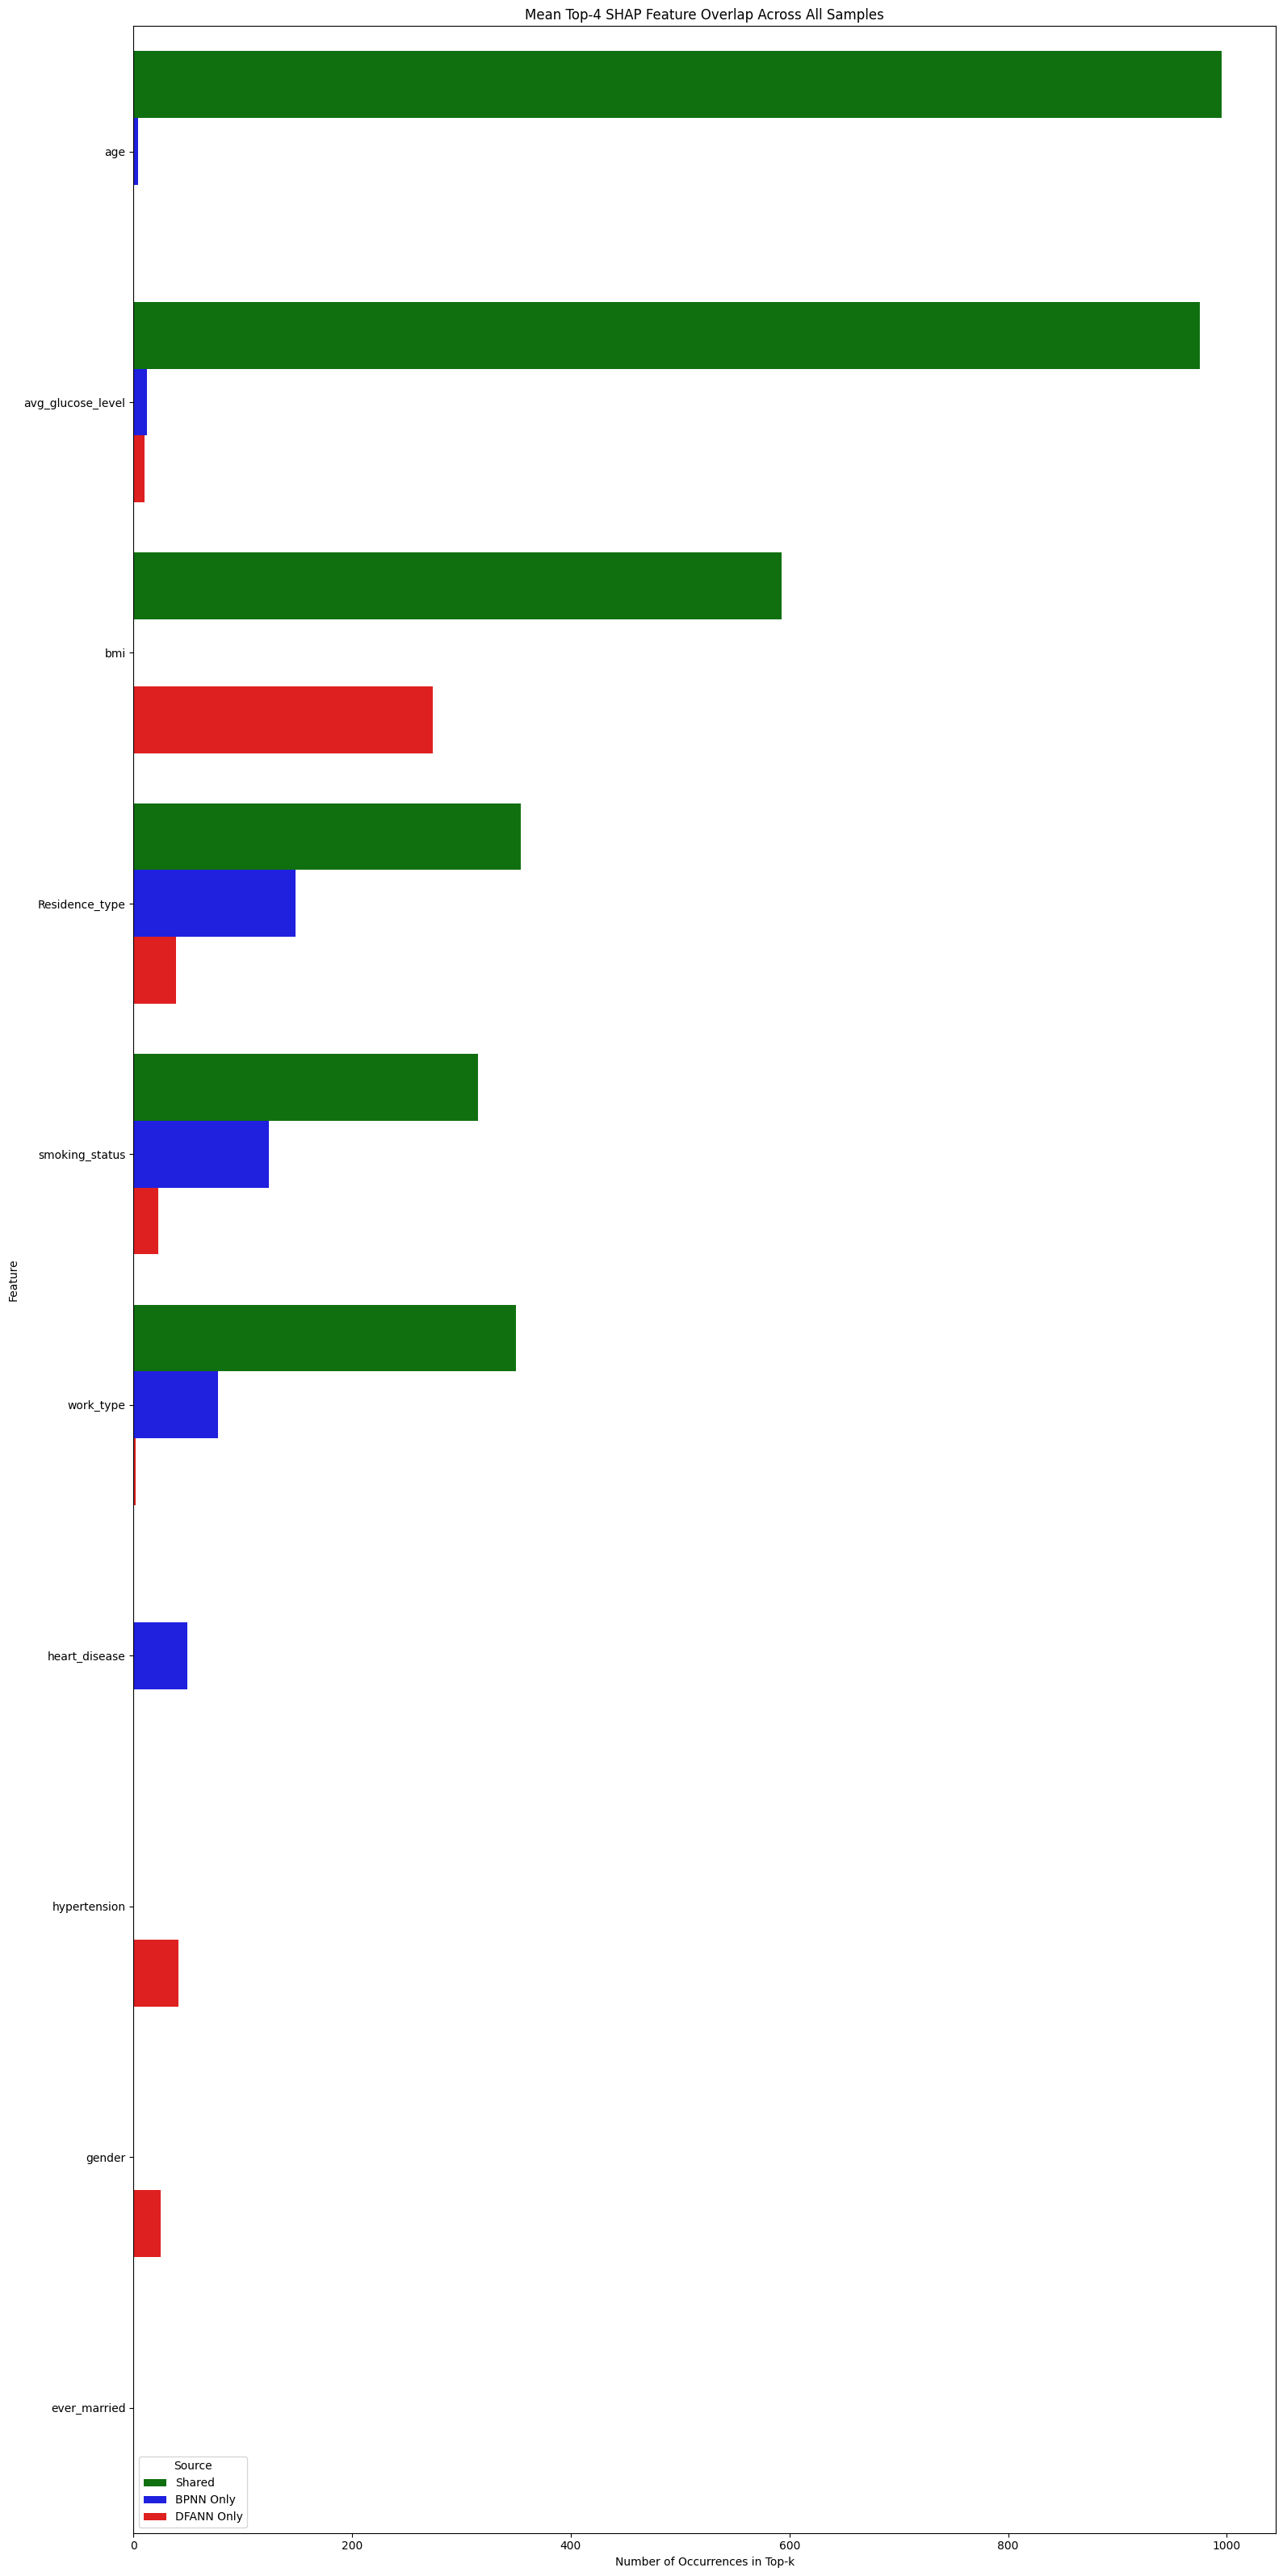

In [20]:
n_samples, n_features = bp_attr.shape
feature_counts = {fn: {"Shared": 0, "BPNN Only": 0, "DFANN Only": 0} for fn in FEATURE_NAMES}

for i in range(n_samples):
    topk_bp = set(np.argsort(np.abs(bp_attr[i]))[-k:])
    topk_dfa = set(np.argsort(np.abs(dfa_attr[i]))[-k:])

    shared = topk_bp & topk_dfa
    only_bp = topk_bp - topk_dfa
    only_dfa = topk_dfa - topk_bp

    for idx in shared:
        feature_counts[FEATURE_NAMES[idx]]["Shared"] += 1
    for idx in only_bp:
        feature_counts[FEATURE_NAMES[idx]]["BPNN Only"] += 1
    for idx in only_dfa:
        feature_counts[FEATURE_NAMES[idx]]["DFANN Only"] += 1

data = []
for feat, counts in feature_counts.items():
    for source, count in counts.items():
        data.append((feat, source, count))
df = pd.DataFrame(data, columns=["Feature", "Source", "Count"])
df["Total"] = df.groupby("Feature")["Count"].transform("sum")
df = df.sort_values("Total", ascending=False)

plt.figure(figsize=(16, 32))
sns.barplot(data=df, y="Feature", x="Count", hue="Source", palette={
    "Shared": "green",
    "BPNN Only": "blue",
    "DFANN Only": "red"
})
plt.title(f"Mean Top-{k} SHAP Feature Overlap Across All Samples")
plt.xlabel("Number of Occurrences in Top-k")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("learning_results/plots/top_k_shap_overlap.png", bbox_inches='tight')
plt.show()